# Visualization

In [ ]:
'''
- matplotlib
- seaborn
- plotly
'''

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
employee_name = ['Bob', 'Arthur', 'Bill', 'Dutch', 'Sadie']
salary = [20000, 30000, 10000, 40000, 35000]
bonus = [5000, 10000, 2000, 15000, 13570]

## Line Plot

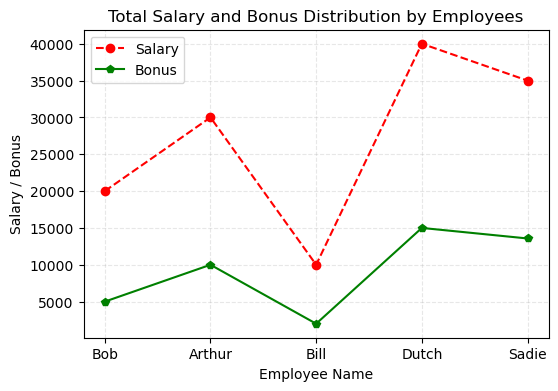

In [3]:
plt.figure(figsize=(6, 4)) # 600 x 400 pxl
plt.plot(employee_name, salary, color='red', marker='o', linestyle='--', label='Salary')
plt.plot(employee_name, bonus, color='green', marker='p', label='Bonus')
plt.xlabel('Employee Name')
plt.ylabel('Salary / Bonus')
plt.title('Total Salary and Bonus Distribution by Employees')
plt.grid(alpha=0.3, linestyle='dashed')
plt.legend()
plt.savefig('salary_bonus.png')
plt.show()

## Bar Plot

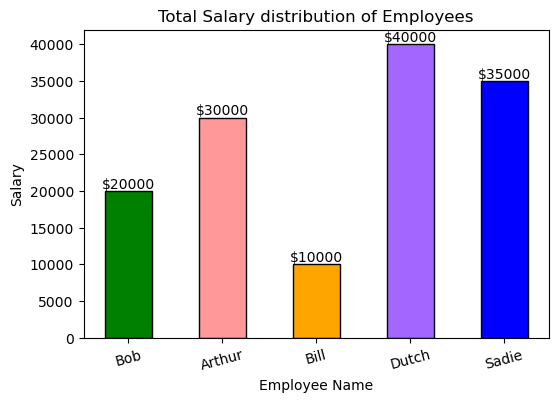

In [4]:
plt.figure(figsize=(6, 4))
plt.bar(employee_name, salary, color=['green', '#ff9999', 'orange', '#a366ff', 'blue'], width=0.5, edgecolor='black')
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Total Salary distribution of Employees')
plt.xticks(rotation=15)

# ha = 'left/right/center', va='top/bottom/center'
for idx, val in enumerate(salary):
    plt.text(idx, val, f'${val}', ha='center', va='bottom')

plt.show()

In [5]:
df = pd.read_csv('hr_cleaned_data.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Salary_Label,salary_label_num,PerformanceScore_id,HireDay_Name_id,E_FirstName,E_MiddleName,E_LastName,M_first_name,M_middle_name,M_last_name
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,Low Salary,0,0,0,Wilson,K,Adinolfi,Michael,NaN,Albert
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,Medium Salary,1,1,1,Karthikeyan,NaN,Ait Sidi,Simon,NaN,Roup
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,Low Salary,0,1,0,Sarah,NaN,Akinkuolie,Kissy,NaN,Sullivan
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,Low Salary,0,1,1,Trina,NaN,Alagbe,Elijiah,NaN,Gray
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Low Salary,0,1,1,Carol,NaN,Anderson,Webster,NaN,Butler


## Pie Chart

In [6]:
perf_emp = df.groupby('PerformanceScore')['EmpID'].count().reset_index()
perf_emp

,PerformanceScore,EmpID
0,Exceeds,97
1,Fully Meets,454
2,Needs Improvement,18
3,PIP,13


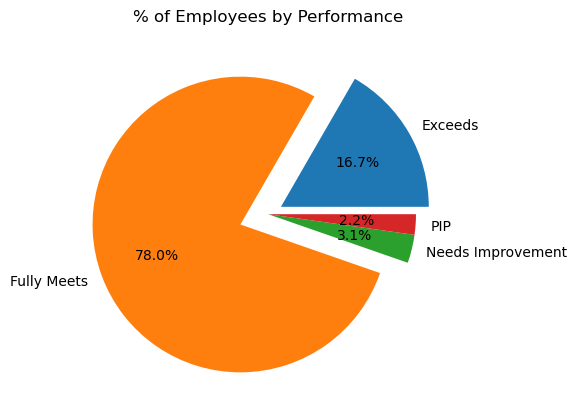

In [7]:
plt.pie(
    perf_emp['EmpID'],
    labels=perf_emp['PerformanceScore'],
    autopct = '%1.1f%%',
    explode = (0.1, 0.2, 0, 0)
)
plt.title('% of Employees by Performance')
plt.show()

## Donut Chart

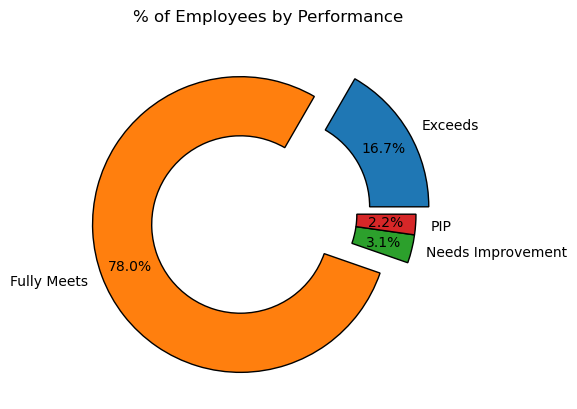

In [8]:
plt.pie(
    perf_emp['EmpID'],
    labels=perf_emp['PerformanceScore'],
    autopct = '%1.1f%%',
    # width edge properties
    wedgeprops = {'width': 0.4, 'edgecolor':'#000'},
    pctdistance=0.8,
    explode = (0.1, 0.2, 0, 0)
)
plt.title('% of Employees by Performance')
plt.show()

## Scatter Plot

In [9]:
temp = pd.read_csv('Dataset/temperature.csv')
temp.head()

,Temperature (°C),Humidity (%)
0,23.745401,57.186649
1,29.507143,66.765614
2,27.319939,64.034868
3,25.986585,60.921443
4,21.560186,49.099373


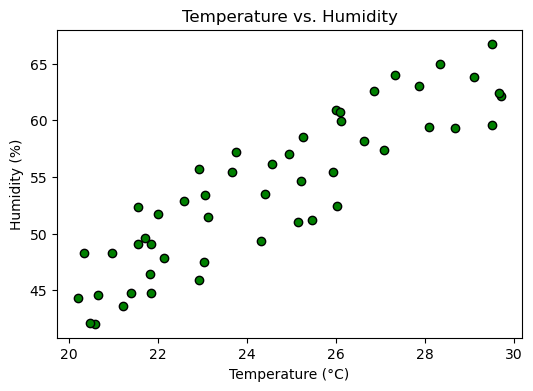

In [10]:
'''
- Both x-axis and y-axis values must be continuous.
'''
plt.figure(figsize=(6, 4))
plt.scatter(temp['Temperature (°C)'], temp['Humidity (%)'], color='green', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs. Humidity')
plt.show()

## Correlation Data

In [11]:
'''
- Pearson Correlation -> Data
- Spearsman Correlation

-- Only integer / float
'''

'\n- Pearson Correlation -> Data\n- Spearsman Correlation\n\n-- Only integer / float\n'

In [12]:
corr_columns = df.select_dtypes(['int', 'float'])
corr_columns = corr_columns.drop(columns=['EmpID', 'HireYear', 'HireMonth', 
                                          'HireDay', 'salary_label_num', 'PerformanceScore_id', 'HireDay_Name_id'])
# corr_columns

In [13]:
corr_data = corr_columns.corr()
# corr_data

<Axes: >

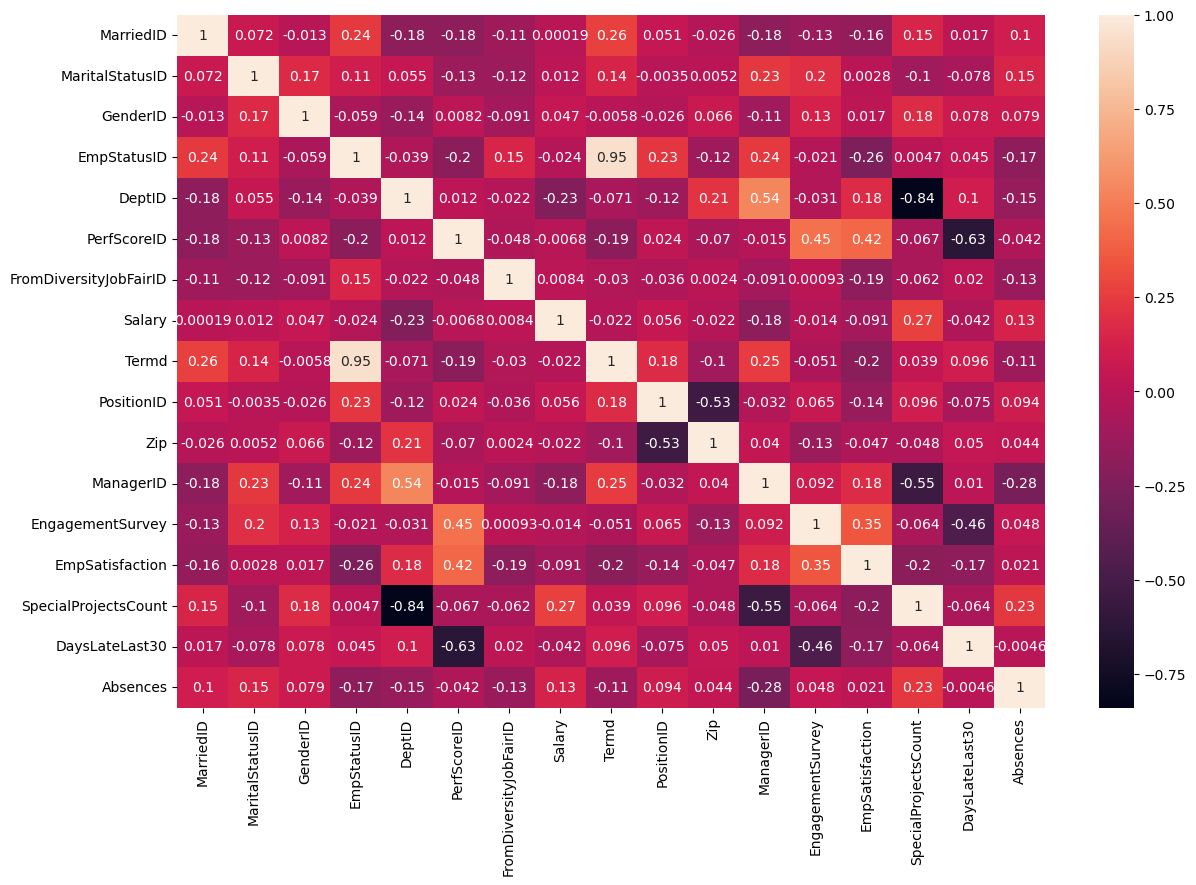

In [14]:
plt.figure(figsize=(14, 9))
sns.heatmap(corr_data, annot=True)

## Histogram

In [15]:
'''
- Number of employees who earns low salary is higher than number of employees who earns high salary.
'''

'\n- Number of employees who earns low salary is higher than number of employees who earns high salary.\n'

In [16]:
filter_salary = df[df['Salary'] < 87000]

In [17]:
salary = filter_salary['Salary']
salary_skew = filter_salary['Salary'].skew()
print(salary_skew)

0.38894271311424977


In [18]:
plt.hist(salary, edgecolor='black')
plt.xlabel('Salary')
plt.ylabel('Frequency / Number of Employees')
plt.close()

In [19]:
mean_salary = salary.mean()
median_salary = salary.median()

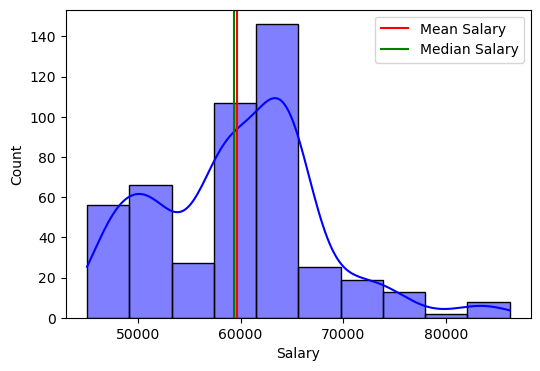

In [20]:
plt.figure(figsize=(6, 4))
# kde -> Kernel Density Estimator
sns.histplot(salary, bins=10, kde=True, color='blue')
# axvline -> axis vertical line
plt.axvline(mean_salary, color='red', label='Mean Salary')
plt.axvline(median_salary, color='green', label='Median Salary')
plt.legend()
plt.show()

### Box Plot

In [21]:
'''
- circle -> Outliers
- T-shape -> Wishkers
- Middle Line -> Median Line
'''

'\n- circle -> Outliers\n- T-shape -> Wishkers\n- Middle Line -> Median Line\n'

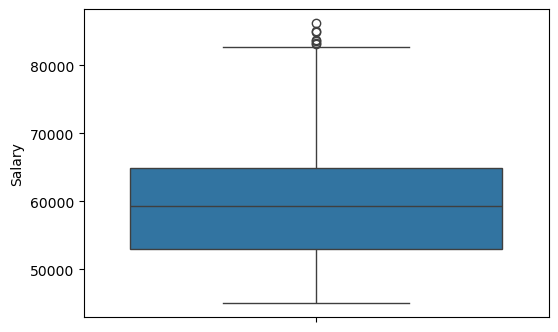

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(salary)
plt.show()

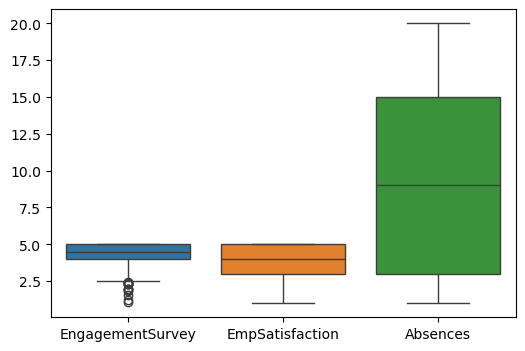

In [23]:
plt.figure(figsize=(6, 4))
sns.boxplot(filter_salary[['EngagementSurvey', 'EmpSatisfaction', 'Absences']])
plt.show()

## Column Chart

In [24]:
# df.columns
# Find total employees by each department and gender

dep_gen = df.groupby(['Department', 'Gender'])['EmpID'].count().reset_index().rename(
    columns = {'EmpID': 'Total Employees'}
)
# dep_gen

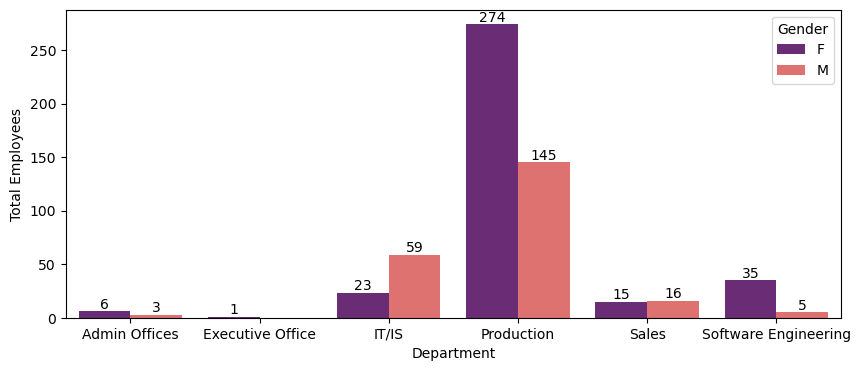

In [25]:
'''
- hue -> used to create column chart.
'''
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=dep_gen, x='Department', y='Total Employees', palette='magma', hue='Gender', errorbar=None)

for container in ax.containers:
    plt.bar_label(container)

plt.show()

## Sub-Plots

In [26]:
dep_details = df.groupby('Department').agg(
    Total_Employees = ('EmpID', 'count'),
    Total_Salary = ('Salary', 'sum'),
    Total_Absences = ('Absences', 'sum'),
    Total_Projects = ('SpecialProjectsCount', 'sum')
).reset_index()
dep_details.columns = dep_details.columns.str.replace('_', ' ', regex=False)
dep_details

,Department,Total Employees,Total Salary,Total Absences,Total Projects
0,Admin Offices,9,646127,78,33
1,Executive Office,1,250000,10,0
2,IT/IS,82,8134411,1048,486
3,Production,419,26949336,3914,4
4,Sales,31,2140899,358,0
5,Software Engineering,40,4373364,647,162


In [49]:
def formatValue(val):
    if abs(val) >= 1e9:
        return f'{val / 1e9:,.2f}B'
    elif abs(val) >= 1e6:
        return f'{val / 1e6:,.2f}M'
    elif abs(val) >= 1e3:
        return f'{val / 1e3:,.2f}K'
    else:
        return f'{val}'

def showValue(dataframe, col_name, ax):
    for idx, val in enumerate(dataframe[col_name]):
        formatted_value = formatValue(val)
        ax.text(idx, val, formatted_value, ha='center', va='bottom')

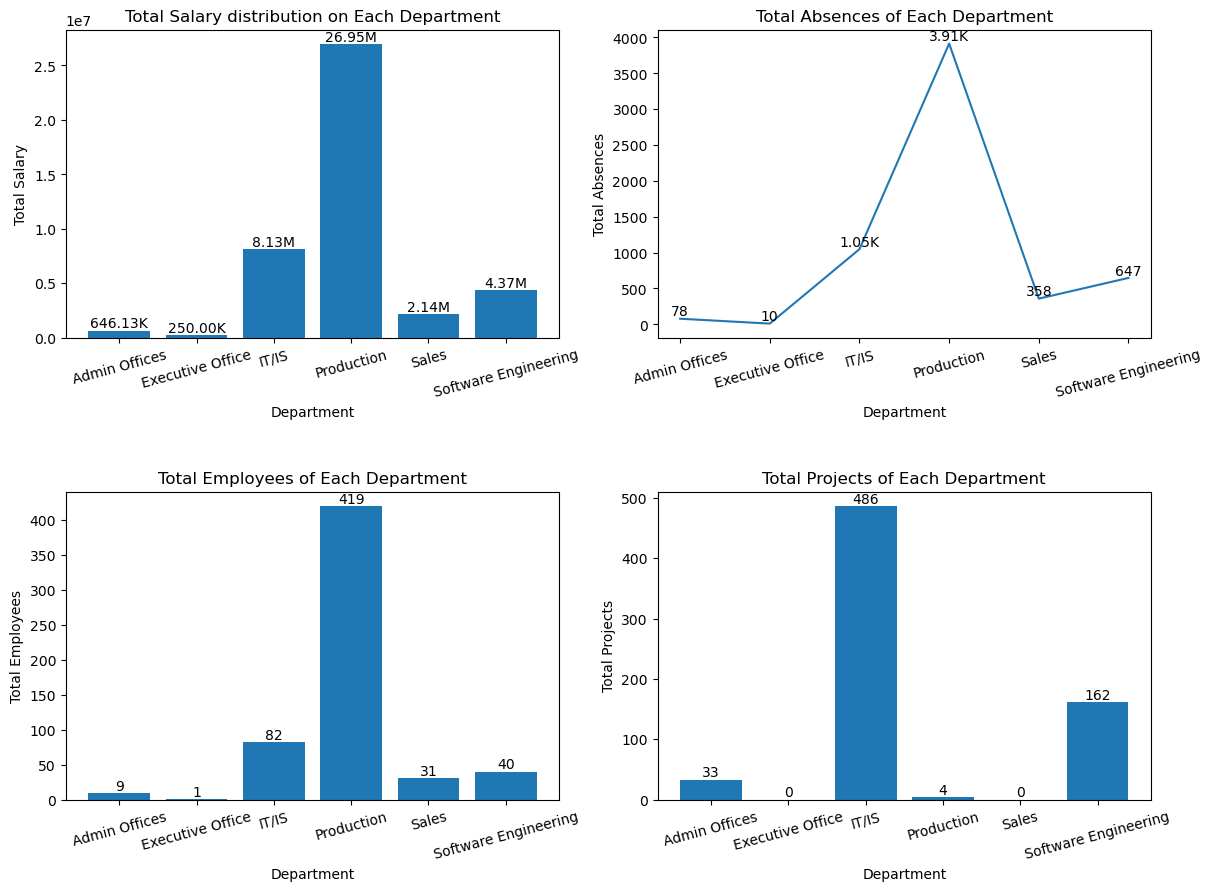

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# wspace -> width space
plt.subplots_adjust(hspace=0.5)

ax1 = axes[0, 0]
ax1.bar(dep_details['Department'], dep_details['Total Salary'])
ax1.set_xlabel('Department')
ax1.set_ylabel('Total Salary')
ax1.set_title('Total Salary distribution on Each Department')
ax1.tick_params(axis='x', rotation=15)

showValue(dep_details, 'Total Salary', ax1)

ax2 = axes[0, 1]
ax2.plot(dep_details['Department'], dep_details['Total Absences'])
ax2.set_xlabel('Department')
ax2.set_ylabel('Total Absences')
ax2.set_title('Total Absences of Each Department')
ax2.tick_params(axis='x', rotation=15)

showValue(dep_details, 'Total Absences', ax2)

ax3 = axes[1, 0]
ax3.bar(dep_details['Department'], dep_details['Total Employees'])
ax3.set_xlabel('Department')
ax3.set_ylabel('Total Employees')
ax3.set_title('Total Employees of Each Department')
ax3.tick_params(axis='x', rotation=15)

showValue(dep_details, 'Total Employees', ax3)

ax4 = axes[1, 1]
ax4.bar(dep_details['Department'], dep_details['Total Projects'])
ax4.set_xlabel('Department')
ax4.set_ylabel('Total Projects')
ax4.set_title('Total Projects of Each Department')
ax4.tick_params(axis='x', rotation=15)
showValue(dep_details, 'Total Projects', ax4)

plt.show()